<a href="https://colab.research.google.com/github/JoudAlrubaish/technical-support-agent/blob/main/notebooks/01_model_a_intent_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Model A — Intent Classifier**

## 1. Environment Setup


In [1]:
#check the runtime
import torch
import sys

print("Python:", sys.version)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
CUDA available: True
GPU: Tesla T4


In [2]:
#clone GitHub project into colab
!git clone https://github.com/JoudAlrubaish/technical-support-agent.git
%cd technical-support-agent


Cloning into 'technical-support-agent'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 3), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), done.
Resolving deltas: 100% (3/3), done.
/content/technical-support-agent


In [3]:
#checking after clone
!pwd
!ls

/content/technical-support-agent
data		     Dockerfile  README.md	   src
DESIGN_DECISIONS.md  models	 reports	   tests
docker-compose.yml   notebooks	 requirements.txt


In [4]:
%cd /content/technical-support-agent
!git pull

/content/technical-support-agent
Already up to date.


In [5]:
!pip install -q -r requirements.txt

In [6]:
#import the requirments
import torch
import transformers
import datasets
import sklearn
import pandas as pd
import numpy as np

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Datasets: 4.8.5
CUDA available: True
GPU: Tesla T4


## 2. Dataset Loading & Inspection

In [104]:
#add HuggingFace token
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")

login(token=hf_token)

In [7]:
#load dataset IT Support V2 dataset from HuggingFace
# This dataset contains technical support conversations in a "messages" format
from datasets import load_dataset

dataset = load_dataset(
    "benjaminmacklin/IT_Support_V2",
    split="train",
    token=hf_token
)

dataset

README.md:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

Mack_training_data .jsonl: reconstructing file:   0%|          |  0.00B / 27.1MB            

Mack_training_data .jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/103226 [00:00<?, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 103226
})

In [8]:
#checking
print(dataset[0]["messages"])

[{'role': 'user', 'content': 'Outlook cannot read emails from Exchange with large attachments.'}, {'role': 'assistant', 'content': 'outlook_issue'}]


## 3. User Message Extraction


In [11]:
#extract only the user message because Model A must classify the incoming support request

"""The original dataset stores each example as a list of messages between the user and the support assistant.
For intent classification,only the user's request is needed as the model input. """

def extract_user_text(example):
    for message in example["messages"]:
        if message["role"] == "user":
            return {"text": message["content"]}

    return {"text": ""}

data = dataset.map(extract_user_text)

Map:   0%|          | 0/103226 [00:00<?, ? examples/s]

In [12]:
#checking few records after applying extract_user_text method

for i in range(5):
    print(f"\n Example {i+1}:")
    print(data[i]["text"])


 Example 1:
Outlook cannot read emails from Exchange with large attachments.

 Example 2:
Resolve inconsistent printer paper jam detection.

 Example 3:
Explain how Mack detects data masking rule bypasses.

 Example 4:
Ax'think my corporate laptop screen resolution changed.

 Example 5:
VPN client shows 'authentication failure' for specific users during business travel.


## 4. Intent Taxonomy Construction

- model A required text and label to be classified, but our dataset does not contain labels so this is what we will do in this part.

In [28]:
# define keyword patterns for each technical support intent

"""These patterns are used only to identify potential training examples.
They are not treated as the final model predictions."""

import re
import pandas as pd
import random

random.seed(42)

intent_patterns = {

    "authentication": [
        r"\blogin\b",
        r"\blog in\b",
        r"\bsign in\b",
        r"\bauthenticat\w*\b",
        r"\bmfa\b",
        r"\b2fa\b",
        r"\bsso\b",
        r"\bcredential",
        r"\bpassword reset\b",
        r"\bpassword sync",
        r"\bpassword synchronization\b",
       r"\binvalid password\b",
       r"\bexpired password\b",
       r"\baccount lock",
       r"\bconditional access\b"
    ],

    "network": [
        r"\bvpn\b",
        r"\bwifi\b",
        r"\bwi-fi\b",
        r"\bdns\b",
        r"\bnetwork\b",
        r"\blatency\b",
        r"\bpacket loss\b",
        r"\brouter\b",
        r"\bfirewall\b"
    ],

    "deployment": [
       r"\bdeploy\w*\b",
       r"\bdocker\b",
       r"\bkubernetes\b",
       r"\bk8s\b",
       r"\bpod\b",
       r"\bhelm\b"
    ],

    "database": [
        r"\bdatabases?\b",
        r"\bpostgres",
        r"\bmysql\b",
        r"\bsql server\b",
        r"\bmongodb\b",
        r"\bdb connection\b",
        r"\bconnection pool\b"
    ],

    "gpu": [
        r"\bgpu\b",
        r"\bcuda\b",
        r"\bnvidia\b",
        r"\bvram\b",
        r"\bgpu memory\b"
    ],

    "api": [
        r"\bapi\b",
        r"\bendpoint\b",
        r"\brest api\b",
        r"\bwebhook\b",
        r"\bhttp 4\d\d\b",
        r"\bhttp 5\d\d\b"
    ],

    "package": [
        r"\bpip\b",
        r"\bnpm\b",
        r"\bpackage\b",
        r"\bdependency\b",
        r"\bdependencies\b",
        r"\bversion conflict\b",
        r"\blibrary version\b"
    ]
}

In [29]:
def find_matching_intents(text):
    """
    Identify all intent categories that match a given support request.

    The function compares the input text against predefined regular
    expression patterns for each intent. Multiple intents may be returned
    when a request contains overlapping technical concepts.

    """

    text = text.lower()

    matches = []

    for intent, patterns in intent_patterns.items():
        if any(re.search(pattern, text) for pattern in patterns):
            matches.append(intent)

    return matches

In [30]:
#checking the intent matching function using an ambiguous example

example = "VPN client shows 'authentication failure' for specific users during business travel."

find_matching_intents(example)

['authentication', 'network']

In [31]:
# build a high-confidence candidate dataset
"""Only examples that match exactly one intent are selected, while examples matching multiple intents are excluded to reduce
 ambiguity and label noise in the training dataset."""

candidates = []

for row in data:
    text = row["text"].strip()

    if not text:
        continue

    matches = find_matching_intents(text)

    if len(matches) == 1:
        candidates.append({
            "text": text,
            "label": matches[0]
        })

# convert the selected candidate examples into a Pandas DataFrame
candidate_df = pd.DataFrame(candidates)

candidate_df.head()

,text,label
0,Diagnose and resolve VPN client event ID 2009.,network
1,"Mack, my corporate VPN connection drops freque...",network
2,Slow network speed compared to others.,network
3,Explain how to deploy a Windows update across ...,deployment
4,Enable Dell Precision workstation diagnostic m...,network


In [32]:
# count the number of candidate examples available for each intent to check if there is enough data and check for balancing
candidate_counts = candidate_df["label"].value_counts()
candidate_counts

,count
label,
network,13534
authentication,3232
deployment,2254
database,1419
api,674
gpu,376
package,284


In [33]:
# inspect random examples from each intent category

for label in intent_patterns.keys():

    print(f"\n{'='*60}")
    print(label.upper())
    print("="*60)

    samples = candidate_df[
        candidate_df["label"] == label
    ].sample(
        min(5, sum(candidate_df["label"] == label)),
        random_state=42
    )

    for text in samples["text"]:
        print("-", text)


AUTHENTICATION
- Domain-joined Windows laptop cannot authenticate to Active Directory.
- Explain how Mack detects slow login performance.
- Explain how Mack detects slow login performance.
- Mack, my corporate account is showing 'Two-Factor Authentication Required' for login.
- Explain how Mack detects slow login performance.

NETWORK
- Explain how Mack manages network bandwidth allocation.
- Resolve DNS resolution failures.
- Network adapter driver causing high CPU usage.
- Legacy network adapter driver unavailable.
- Lenovo docking station network adapter works but has intermittent connectivity.

DEPLOYMENT
- Fix inconsistent Kubernetes resource limits.
- Fix missing printer drivers during deployment.
- Fix SCCM patch deployment failure.
- Explain how Mack deploys Azure DevOps release pipelines.
- Address Azure Kubernetes Service cluster issues.

DATABASE
- Mack, I can't connect to the company's internal database.
- Explain how Mack identifies slow database backup verification.
- Ex

## 5. Balanced Dataset Creation

- The candidate dataset is highly imbalanced, with some intent classes
containing thousands of examples and others containing only a few hundred.

- Before balancing, duplicate requests are removed to reduce the risk of
data leakage between the training, validation, and test sets.


In [34]:
#remove duplicates
candidate_df = (
    candidate_df
    .drop_duplicates(subset="text")
    .reset_index(drop=True)
)

print("Candidate examples after removing duplicates:", len(candidate_df))

candidate_df["label"].value_counts()

Candidate examples after removing duplicates: 15051


,count
label,
network,9036
authentication,2208
deployment,1744
database,1055
api,548
gpu,283
package,177


In [35]:
# define patterns representing general requests that do not belong to any of the seven specialist intents

general_patterns = [
    r"\bprinter\b",
    r"\bprinting\b",
    r"\boutlook\b",
    r"\bemail\b",
    r"\bkeyboard\b",
    r"\bmouse\b",
    r"\bscreen\b",
    r"\bdisplay\b",
    r"\blaptop\b",
    r"\bmonitor\b",
    r"\bfile\b",
    r"\bfolder\b",
    r"\bstorage\b",
    r"\bsoftware\b",
    r"\bapplication\b",
    r"\bwindows\b",
    r"\bmac\b"
]

In [36]:
general_candidates = []

for row in data:

    text = row["text"].strip()

    # skip empty messages
    if not text:
        continue

    # check whether the request belongs to a specialist intent
    specialist_matches = find_matching_intents(text)

    # general examples must not match any specialist intent
    if len(specialist_matches) != 0:
        continue

    text_lower = text.lower()

    # keep requests clearly related to general IT support
    if any(re.search(pattern, text_lower) for pattern in general_patterns):
        general_candidates.append({
            "text": text,
            "label": "general"
        })

general_df = pd.DataFrame(general_candidates)

# remove duplicate general requests
general_df = (
    general_df
    .drop_duplicates(subset="text")
    .reset_index(drop=True)
)

print("General candidates:", len(general_df))

General candidates: 22047


In [37]:
#inspect the general examples
general_df.sample(
    n=min(10, len(general_df)),
    random_state=42
)

,text,label
4539,"Mack, my monitor is flickering and not display...",general
19367,Resolve blue screen error with stop code 0x000...,general
2645,Outlook 2016 stuck on 'Loading Headers' for em...,general
2255,"Mack, I keep getting the 'Error 0x8024700D' Wi...",general
9942,Windows activation error 0x80072528 during OOBE.,general
13461,Windows 10 activation error after hardware cha...,general
6091,Windows 11 event viewer shows 'Certificate Req...,general
4400,Configure Windows Storage Spaces for file serv...,general
812,"Mack, my HP printer shows 'Replace cartridge' ...",general
7814,Epson printer shows 'Paper Jam' falsely detected.,general


In [38]:
#create the balanced dataset
#i choosed to use 50 example from each intent instade of 12

SAMPLES_PER_CLASS = 50

balanced_parts = []

# sample the same number of examples from each specialist class
for label in intent_patterns.keys():

    class_samples = (
        candidate_df[candidate_df["label"] == label]
        .sample(
            n=SAMPLES_PER_CLASS,
            random_state=42
        )
    )

    balanced_parts.append(class_samples)

# add the same number of general examples.
general_samples = general_df.sample(
    n=SAMPLES_PER_CLASS,
    random_state=42
)

balanced_parts.append(general_samples)

# combine all eight classes.
balanced_df = pd.concat(
    balanced_parts,
    ignore_index=True
)

In [39]:
#shuffle the data
balanced_df = (
    balanced_df
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

balanced_df.head()

,text,label
0,"Mack, my dedicated GPU shows low performance.",gpu
1,Fix Azure API Management gateway CORS configur...,api
2,M365 user unable to reset password using Micro...,authentication
3,BSOD with VIDEO_TDR_FAILURE due to NVIDIA driv...,gpu
4,"Mack, I need to disable Windows 11's firewall ...",network


In [40]:
# verify that every intent contains the same number of examples

balanced_counts = balanced_df["label"].value_counts()
balanced_counts

,count
label,
gpu,50
api,50
authentication,50
network,50
package,50
deployment,50
general,50
database,50


In [42]:
#final check
print("Total examples:", len(balanced_df))
print("Number of classes:", balanced_df["label"].nunique())
print("Duplicate texts:", balanced_df["text"].duplicated().sum())

Total examples: 400
Number of classes: 8
Duplicate texts: 0


## 6. Label Encoding

- The intent labels are currently stored as text values such as **authentication** for sequence classification each intent must be represented by a numeric class ID




In [43]:
# define the labels to be map to 0-7 labels

LABELS = [
    "authentication",
    "network",
    "deployment",
    "database",
    "gpu",
    "api",
    "package",
    "general"
]

In [44]:
# create mappings between text labels and numeric class IDs

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print("label2id:" , label2id)
print("\nid2label:" , id2label)


label2id: {'authentication': 0, 'network': 1, 'deployment': 2, 'database': 3, 'gpu': 4, 'api': 5, 'package': 6, 'general': 7}

id2label: {0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}


In [45]:
# convert each text label into its corresponding numeric class ID

balanced_df["label_id"] = balanced_df["label"].map(label2id)
balanced_df.head()

,text,label,label_id
0,"Mack, my dedicated GPU shows low performance.",gpu,4
1,Fix Azure API Management gateway CORS configur...,api,5
2,M365 user unable to reset password using Micro...,authentication,0
3,BSOD with VIDEO_TDR_FAILURE due to NVIDIA driv...,gpu,4
4,"Mack, I need to disable Windows 11's firewall ...",network,1


In [46]:
# verify that every text label was successfully encoded

print("Missing label IDs:", balanced_df["label_id"].isna().sum())
balanced_df[["label", "label_id"]].drop_duplicates().sort_values("label_id")

Missing label IDs: 0


,label,label_id
2,authentication,0
4,network,1
9,deployment,2
31,database,3
0,gpu,4
1,api,5
6,package,6
11,general,7


## 7. Train / Validation / Test Split

- The balanced dataset divided into three subsets 80% Training, 10% Validation, and 10% Test set.
- Stratified splitting is used to preserve the same class distribution
across all subsets.


In [47]:
from sklearn.model_selection import train_test_split

# first split : 80% training and 20% temporary data for validation + testing
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.20,
    random_state=42,
    stratify=balanced_df["label_id"]
)

# second split: divide the remaining 20% equally into validation and test sets
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

# reset indices for clean datasets
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [48]:
#checking
print("Train examples:", len(train_df))
print("Validation examples:", len(val_df))
print("Test examples:", len(test_df))

Train examples: 320
Validation examples: 40
Test examples: 40


In [49]:
#verify stratification
print("TRAIN")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["label"].value_counts().sort_index())

print("\nTEST")
print(test_df["label"].value_counts().sort_index())

TRAIN
label
api               40
authentication    40
database          40
deployment        40
general           40
gpu               40
network           40
package           40
Name: count, dtype: int64

VALIDATION
label
api               5
authentication    5
database          5
deployment        5
general           5
gpu               5
network           5
package           5
Name: count, dtype: int64

TEST
label
api               5
authentication    5
database          5
deployment        5
general           5
gpu               5
network           5
package           5
Name: count, dtype: int64


In [50]:
# Verify that no text example appears in more than one data split.

train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("Train ↔ Validation overlap:", len(train_texts & val_texts))
print("Train ↔ Test overlap:", len(train_texts & test_texts))
print("Validation ↔ Test overlap:", len(val_texts & test_texts))

Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


## 8. Baseline Model Evaluation

- before fine-tuning, the base DistilBERT model is evaluated on the
held-out test set to establish a baseline.

In [51]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


from transformers import set_seed

set_seed(42)
MODEL_A = "distilbert-base-uncased"

# load the pretrained tokenizer
baseline_tokenizer = AutoTokenizer.from_pretrained(MODEL_A)

# load DistilBERT with a new classification head for the eight intents
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_A,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
)

# move the model to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

baseline_model.to(device)
baseline_model.eval()

print("Device:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cuda


In [53]:
#define evaluation function
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def evaluate_baseline(model, tokenizer, dataframe, device):
    """
    Evaluate the unfine-tuned intent classification model.

    The function tokenizes the test examples, performs inference,
    and calculates accuracy and macro-averaged precision, recall,
    and F1 score.

    """

    predictions = []
    true_labels = dataframe["label_id"].tolist()

    for text in dataframe["text"]:

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=128
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = model(**inputs)

        predicted_id = int(
            torch.argmax(outputs.logits, dim=-1).item()
        )

        predictions.append(predicted_id)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="macro",
        zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

    return metrics, predictions

In [55]:
#run the baseline
baseline_metrics, baseline_predictions = evaluate_baseline(
    model=baseline_model,
    tokenizer=baseline_tokenizer,
    dataframe=test_df,
    device=device
)


#display the baseline results
print("Baseline Results")
print("---------------------------")
print(f"Accuracy        : {baseline_metrics['accuracy']:.4f}")
print(f"Macro Precision : {baseline_metrics['precision_macro']:.4f}")
print(f"Macro Recall    : {baseline_metrics['recall_macro']:.4f}")
print(f"Macro F1        : {baseline_metrics['f1_macro']:.4f}")

Baseline Results
---------------------------
Accuracy        : 0.1250
Macro Precision : 0.0156
Macro Recall    : 0.1250
Macro F1        : 0.0278


In [56]:
#save the baseline results
model_a_results = {
    "baseline": {
        "accuracy": baseline_metrics["accuracy"],
        "precision_macro": baseline_metrics["precision_macro"],
        "recall_macro": baseline_metrics["recall_macro"],
        "f1_macro": baseline_metrics["f1_macro"]
    }
}

model_a_results

{'baseline': {'accuracy': 0.125,
  'precision_macro': 0.015625,
  'recall_macro': 0.125,
  'f1_macro': 0.027777777777777776}}

## 9. Tokenization


In [57]:
from datasets import Dataset

# convert the Pandas splits into Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(
    train_df[["text", "label_id"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label_id"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label_id"]],
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label_id'],
    num_rows: 320
})
Dataset({
    features: ['text', 'label_id'],
    num_rows: 40
})
Dataset({
    features: ['text', 'label_id'],
    num_rows: 40
})


In [58]:
#load tokenizer
from transformers import AutoTokenizer
tokenizer_a = AutoTokenizer.from_pretrained(MODEL_A)

In [59]:
#tokenization function
def tokenize_a(batch):
    """
    The function converts raw text into token IDs and attention masks.
    Requests longer than 128 tokens are truncated.

    """

    return tokenizer_a(
        batch["text"],
        truncation=True,
        max_length=128
    )

In [60]:
# apply the same tokenizer to train, validation, and test sets

train_tokenized = train_dataset.map(
    tokenize_a,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_a,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_a,
    batched=True
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [61]:
#rename labels col to match what Huggingface expected
train_tokenized = train_tokenized.rename_column(
    "label_id",
    "labels"
)

val_tokenized = val_tokenized.rename_column(
    "label_id",
    "labels"
)

test_tokenized = test_tokenized.rename_column(
    "label_id",
    "labels"
)

In [62]:
#checking tokenization result
train_tokenized[0]

{'text': 'Fix corrupted SQL Server Agent proxy account.',
 'labels': 3,
 'input_ids': [101, 8081, 27279, 29296, 8241, 4005, 24540, 4070, 1012, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [63]:
#final check
print("Train:", len(train_tokenized))
print("Validation:", len(val_tokenized))
print("Test:", len(test_tokenized))
print("\nAvailable columns:" , train_tokenized.column_names)


Train: 320
Validation: 40
Test: 40

Available columns: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


## 10. DistilBERT Model Setup

- A fresh DistilBERT sequence-classification model is initialized for
fine-tuning on the eight technical-support intent classes.


In [64]:
from transformers import AutoModelForSequenceClassification

# load a fresh DistilBERT model for fine-tuning.
model_a = AutoModelForSequenceClassification.from_pretrained(
    MODEL_A,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
)

model_a

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [66]:
#check trainable parms
total_params = sum(
    p.numel()
    for p in model_a.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_a.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 66,959,624
Trainable parameters : 66,959,624


## 11. Fine-Tuning Configuration

- The model is trained for three epochs using a learning rate of `2e-5`
and a batch size of `8`.

- Macro F1 is used as the primary model-selection metric because all
eight intent classes are equally important.

- Dynamic padding is applied at batch level to avoid unnecessary padding
to the maximum sequence length.

In [67]:
#define evaluation metrics
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_cls_metrics(eval_pred):
    """
    Compute classification metrics for Model A.

    Predictions are converted from model logits into class IDs.
    Accuracy and macro-averaged precision, recall, and F1 are then
    calculated across all eight intent classes.

    """

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [68]:
#apply dynamic padding using DataCollatorWithPadding
from transformers import DataCollatorWithPadding

# dynamically pad each batch to the longest sequence in that batch

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_a)

In [69]:
#set training args

from transformers import TrainingArguments

training_args_a = TrainingArguments(
    output_dir="models/intent_classifier",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    weight_decay=0.01,

    seed=42,

    report_to="none"
)

In [71]:
#create the trainer
from transformers import Trainer

trainer_a = Trainer(
    model=model_a,
    args=training_args_a,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer_a,
    data_collator=data_collator,

    compute_metrics=compute_cls_metrics
)

## 12. Model Training


In [73]:
# fine-tune Model A on the technical-support intent dataset
train_output = trainer_a.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,1.967975,0.300000,0.221078,0.300000,0.235137
2,No log,1.791235,0.500000,0.464583,0.500000,0.465377
3,No log,1.716313,0.525000,0.474306,0.525000,0.483775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [75]:
#check
print(f"Training loss: {train_output.training_loss:.4f}")
print(f"Training steps: {train_output.global_step}")

Training loss: 1.8676
Training steps: 120


### Experiment 2 — Increase Training Epochs

The first experiment showed continuous improvement through Epoch 3,
with decreasing validation loss and increasing Macro F1.

Since there was no indication of overfitting, a second experiment is
conducted using the same dataset and hyperparameters while increasing
the number of training epochs from 3 to 5.

In [76]:
# create a fresh model for Experiment 2
from transformers import set_seed

set_seed(42)

model_a_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_A,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [79]:
#set training args
training_args_exp2 = TrainingArguments(
    output_dir="models/intent_classifier_exp2",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=5, # only change

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    weight_decay=0.01,
    seed=42,

    report_to="none"
)

In [80]:
#create trainer then train the model on the new config
trainer_a_exp2 = Trainer(
    model=model_a_exp2,
    args=training_args_exp2,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer_a,
    data_collator=data_collator,

    compute_metrics=compute_cls_metrics
)

train_output_exp2 = trainer_a_exp2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.073413,0.826046,0.900000,0.918452,0.900000,0.889232
2,0.584133,0.458985,0.925000,0.943452,0.925000,0.914232
3,0.308227,0.340697,0.900000,0.912500,0.900000,0.887338
4,0.203663,0.292056,0.900000,0.912500,0.900000,0.887338
5,0.154542,0.295088,0.925000,0.937500,0.925000,0.912338


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 13. Fine-Tuned Model Evaluation


In [81]:
# evaluate the best fine-tuned checkpoint on the held-out test set

test_results = trainer_a_exp2.evaluate(
    eval_dataset=test_tokenized,
    metric_key_prefix="test"
)

test_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.154542,0.427871,5,0.950000,0.958333,0.950000,0.949495


{'test_loss': 0.42787131667137146,
 'test_accuracy': 0.95,
 'test_precision_macro': 0.9583333333333334,
 'test_recall_macro': 0.95,
 'test_f1_macro': 0.9494949494949495}

In [82]:
print("Fine-Tuned Test Results")
print("---------------------------")
print(f"Accuracy        : {test_results['test_accuracy']:.4f}")
print(f"Macro Precision : {test_results['test_precision_macro']:.4f}")
print(f"Macro Recall    : {test_results['test_recall_macro']:.4f}")
print(f"Macro F1        : {test_results['test_f1_macro']:.4f}")

Fine-Tuned Test Results
---------------------------
Accuracy        : 0.9500
Macro Precision : 0.9583
Macro Recall    : 0.9500
Macro F1        : 0.9495


## 14. Confusion Matrix and Per-Class Analysis



In [83]:
# generate predictions for the held-out test dataset

test_prediction_output = trainer_a_exp2.predict(
    test_tokenized
)

test_logits = test_prediction_output.predictions
test_true_labels = test_prediction_output.label_ids

test_pred_labels = np.argmax(
    test_logits,
    axis=-1
)

print("Number of test predictions:", len(test_pred_labels))

Number of test predictions: 40


In [84]:
from sklearn.metrics import classification_report

# display precision, recall, and F1 score for every intent class

report = classification_report(
    test_true_labels,
    test_pred_labels,
    target_names=LABELS,
    digits=4,
    zero_division=0
)

print(report)

                precision    recall  f1-score   support

authentication     0.8333    1.0000    0.9091         5
       network     1.0000    1.0000    1.0000         5
    deployment     1.0000    0.8000    0.8889         5
      database     1.0000    1.0000    1.0000         5
           gpu     1.0000    1.0000    1.0000         5
           api     1.0000    0.8000    0.8889         5
       package     1.0000    1.0000    1.0000         5
       general     0.8333    1.0000    0.9091         5

      accuracy                         0.9500        40
     macro avg     0.9583    0.9500    0.9495        40
  weighted avg     0.9583    0.9500    0.9495        40



In [85]:
# store the classification report as a dictionary for later quality-gate evaluation

report_dict = classification_report(
    test_true_labels,
    test_pred_labels,
    target_names=LABELS,
    output_dict=True,
    zero_division=0
)

per_class_results = pd.DataFrame(
    report_dict
).transpose()

per_class_results.loc[LABELS, [
    "precision",
    "recall",
    "f1-score",
    "support"
]]

,precision,recall,f1-score,support
authentication,0.833333,1.0,0.909091,5.0
network,1.000000,1.0,1.000000,5.0
deployment,1.000000,0.8,0.888889,5.0
database,1.000000,1.0,1.000000,5.0
gpu,1.000000,1.0,1.000000,5.0
api,1.000000,0.8,0.888889,5.0
package,1.000000,1.0,1.000000,5.0
general,0.833333,1.0,0.909091,5.0


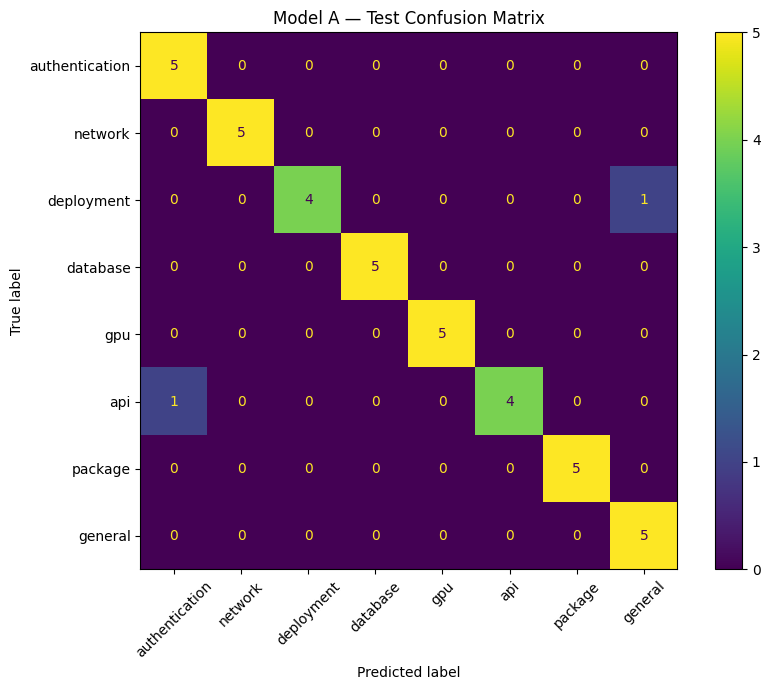

In [86]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

# visualize which intent classes are confused with each other

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    test_true_labels,
    test_pred_labels,
    display_labels=LABELS,
    xticks_rotation=45,
    ax=ax
)

plt.title("Model A — Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [87]:
# inspect the individual test examples that were misclassified

error_rows = []

for i, (true_id, pred_id) in enumerate(
    zip(test_true_labels, test_pred_labels)
):

    if true_id != pred_id:

        error_rows.append({
            "text": test_df.iloc[i]["text"],
            "true_label": id2label[int(true_id)],
            "predicted_label": id2label[int(pred_id)]
        })

errors_df = pd.DataFrame(error_rows)

errors_df

,text,true_label,predicted_label
0,Windows 11 'Windows Update for Business' deplo...,deployment,general
1,M365 SharePoint Online page returns HTTP 503 S...,api,authentication


## 15. Baseline vs Fine-Tuned Comparison


In [88]:
#store model A FINE-TUNED results

model_a_results["fine_tuned"] = {
    "accuracy": test_results["test_accuracy"],
    "precision_macro": test_results["test_precision_macro"],
    "recall_macro": test_results["test_recall_macro"],
    "f1_macro": test_results["test_f1_macro"]
}

model_a_results

{'baseline': {'accuracy': 0.125,
  'precision_macro': 0.015625,
  'recall_macro': 0.125,
  'f1_macro': 0.027777777777777776},
 'fine_tuned': {'accuracy': 0.95,
  'precision_macro': 0.9583333333333334,
  'recall_macro': 0.95,
  'f1_macro': 0.9494949494949495}}

In [89]:
# create a comparison table between baseline and fine-tuned performance

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Baseline": [
        model_a_results["baseline"]["accuracy"],
        model_a_results["baseline"]["precision_macro"],
        model_a_results["baseline"]["recall_macro"],
        model_a_results["baseline"]["f1_macro"]
    ],

    "Fine-Tuned": [
        model_a_results["fine_tuned"]["accuracy"],
        model_a_results["fine_tuned"]["precision_macro"],
        model_a_results["fine_tuned"]["recall_macro"],
        model_a_results["fine_tuned"]["f1_macro"]
    ]
})

comparison_df

,Metric,Baseline,Fine-Tuned
0,Accuracy,0.125000,0.950000
1,Macro Precision,0.015625,0.958333
2,Macro Recall,0.125000,0.950000
3,Macro F1,0.027778,0.949495


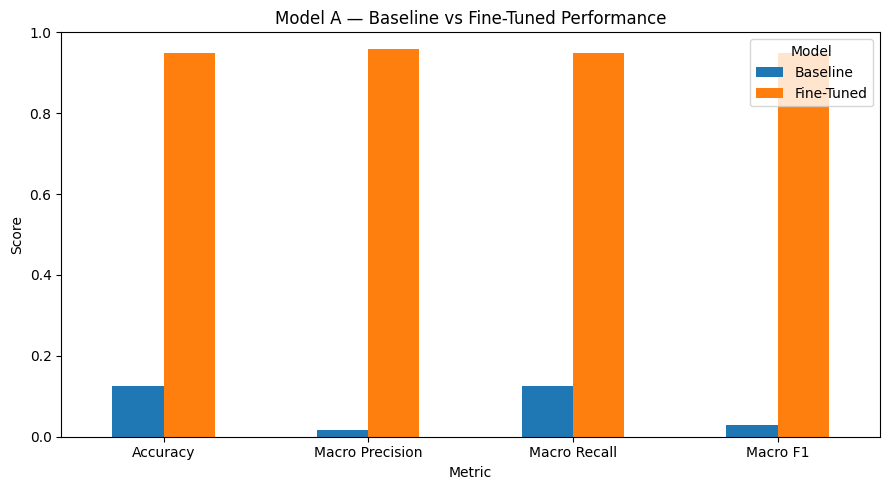

In [90]:
# visualize baseline vs fine-tuned performance

comparison_plot = comparison_df.set_index("Metric")[
    ["Baseline", "Fine-Tuned"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model A — Baseline vs Fine-Tuned Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

####**Experiment Finding**

Fine-tuning substantially improved Model A across all evaluation metrics.

- Accuracy improved from **12.50%** to **95.00%**.
- Macro F1 improved from **0.0278** to **0.9495**.
- Macro Recall improved from **0.1250** to **0.9500**.

The results show that the pretrained DistilBERT model did not initially
distinguish the project-specific technical-support intents, while fine-tuning
enabled strong intent classification performance.

## 16. Quality Gate Evaluation


Model A is evaluated against the project acceptance criteria.

The model passes the quality gate only if:

- Macro F1 is at least **0.80**.
- Recall for every intent class is at least **0.60**.
- The confusion matrix and classification errors are manually reviewed.

This ensures that strong average performance does not hide poor
performance on any individual intent class.

In [91]:
# define the Model A quality-gate thresholds

F1_THRESHOLD = 0.80
MIN_CLASS_RECALL = 0.60

# extract recall for each intent class.
class_recalls = {
    label: report_dict[label]["recall"]
    for label in LABELS
}

class_recalls

{'authentication': 1.0,
 'network': 1.0,
 'deployment': 0.8,
 'database': 1.0,
 'gpu': 1.0,
 'api': 0.8,
 'package': 1.0,
 'general': 1.0}

In [92]:
lowest_recall_class = min(
    class_recalls,
    key=class_recalls.get
)

lowest_recall = class_recalls[
    lowest_recall_class
]

print("Lowest-recall class:", lowest_recall_class)
print(f"Lowest recall: {lowest_recall:.4f}")

Lowest-recall class: deployment
Lowest recall: 0.8000


In [93]:
# evaluate the individual Model A quality-gate conditions

f1_pass = (
    test_results["test_f1_macro"]
    >= F1_THRESHOLD
)

recall_pass = all(
    recall >= MIN_CLASS_RECALL
    for recall in class_recalls.values()
)

print("Macro F1 gate passed:", f1_pass)
print("Per-class recall gate passed:", recall_pass)

Macro F1 gate passed: True
Per-class recall gate passed: True


In [94]:
# Model A passes only if all required quantitative gates pass

model_a_gate_passed = (
    f1_pass
    and recall_pass
)

print(
    "MODEL A QUALITY GATE:",
    "PASSED" if model_a_gate_passed else "FAILED"
)

MODEL A QUALITY GATE: PASSED


In [95]:
#Store the quality-gate result

model_a_results["quality_gate"] = {
    "required_macro_f1": F1_THRESHOLD,
    "actual_macro_f1": test_results["test_f1_macro"],

    "required_min_class_recall": MIN_CLASS_RECALL,
    "actual_min_class_recall": lowest_recall,

    "macro_f1_passed": f1_pass,
    "class_recall_passed": recall_pass,

    "passed": model_a_gate_passed
}

model_a_results

{'baseline': {'accuracy': 0.125,
  'precision_macro': 0.015625,
  'recall_macro': 0.125,
  'f1_macro': 0.027777777777777776},
 'fine_tuned': {'accuracy': 0.95,
  'precision_macro': 0.9583333333333334,
  'recall_macro': 0.95,
  'f1_macro': 0.9494949494949495},
 'quality_gate': {'required_macro_f1': 0.8,
  'actual_macro_f1': 0.9494949494949495,
  'required_min_class_recall': 0.6,
  'actual_min_class_recall': 0.8,
  'macro_f1_passed': True,
  'class_recall_passed': True,
  'passed': True}}

####**Quality Gate Result**

Model A **passed the project quality gate**.

- Test Macro F1: **0.9495**, exceeding the required **0.80**.
- Lowest per-class recall: **0.80**, exceeding the required **0.60**.
- Six of the eight intent classes achieved perfect recall.
- The remaining two classes, `deployment` and `api`, achieved a recall of **0.80**.

The confusion matrix and misclassified examples were manually reviewed
before accepting the model.

## 17. Error Analysis


Although Model A achieved strong overall performance, two test examples
were misclassified.

This section examines the remaining errors to identify possible causes,
such as overlapping terminology, ambiguous intent boundaries, or limited
training examples.

The findings are used to document model limitations and guide future
improvements.

In [96]:
#display misclassified
pd.set_option("display.max_colwidth", None)

errors_df

,text,true_label,predicted_label
0,Windows 11 'Windows Update for Business' deployment not reaching target devices.,deployment,general
1,M365 SharePoint Online page returns HTTP 503 Service Unavailable.,api,authentication


In [97]:
#add confidence score
import torch

# convert logits into probabilities

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1
).numpy()

error_details = []

for i, (true_id, pred_id) in enumerate(
    zip(test_true_labels, test_pred_labels)
):

    if true_id != pred_id:

        confidence = test_probabilities[i][pred_id]

        error_details.append({
            "text": test_df.iloc[i]["text"],
            "true_label": id2label[int(true_id)],
            "predicted_label": id2label[int(pred_id)],
            "confidence": float(confidence)
        })

error_analysis_df = pd.DataFrame(error_details)

error_analysis_df

,text,true_label,predicted_label,confidence
0,Windows 11 'Windows Update for Business' deployment not reaching target devices.,deployment,general,0.446170
1,M365 SharePoint Online page returns HTTP 503 Service Unavailable.,api,authentication,0.383125


In [98]:
# show the three most likely intents for each misclassified example

for i, row in errors_df.iterrows():

    original_index = next(
        idx for idx, text in enumerate(test_df["text"])
        if text == row["text"]
    )

    probs = test_probabilities[original_index]

    top_indices = np.argsort(probs)[::-1][:3]

    print("\nText:")
    print(row["text"])

    print("\nTop predictions:")

    for idx in top_indices:
        print(
            f"{id2label[int(idx)]:15} "
            f"{probs[idx]:.4f}"
        )

    print("-" * 70)


Text:
Windows 11 'Windows Update for Business' deployment not reaching target devices.

Top predictions:
general         0.4462
deployment      0.1330
package         0.1094
----------------------------------------------------------------------

Text:
M365 SharePoint Online page returns HTTP 503 Service Unavailable.

Top predictions:
authentication  0.3831
api             0.1805
general         0.1357
----------------------------------------------------------------------


In [ ]:
# sdd qualitative error categories based on manual review

error_analysis_df["error_category"] = [
    "Intent overlap: deployment vs general",
    "Overlapping context: API vs authentication"
]

error_analysis_df

####**Error Analysis Findings**

Only **2 out of 40** test examples were misclassified.

Both errors occurred with relatively low prediction confidence:

- `deployment → general`: confidence **0.4462**
- `api → authentication`: confidence **0.3831**

This indicates that the model was uncertain rather than confidently
making incorrect predictions.

The first error reflects overlap between general Windows support and
deployment-related terminology.

The second reflects ambiguity between Microsoft 365 service/API errors
and authentication-related support contexts.

These cases support the later use of a classifier confidence threshold:
high-confidence predictions can be routed directly, while low-confidence
requests can fall back to the LLM router.

## 18. Model Saving and Hugging Face Upload


The best Model A checkpoint is saved together with its tokenizer and
label configuration because `load_best_model_at_end=True` was used during training, the Trainer restores the checkpoint with the highest validation Macro F1 before saving.

The saved model can later be loaded by the routing system without
retraining.

In [99]:
#check which checkpoint was selected
print("Best checkpoint:",trainer_a_exp2.state.best_model_checkpoint)
print("Best validation Macro F1:", trainer_a_exp2.state.best_metric)

Best checkpoint: models/intent_classifier_exp2/checkpoint-80
Best validation Macro F1: 0.9142316017316017


In [100]:
#save the model locally
MODEL_A_SAVE_PATH = "models/intent_classifier"

# save the best fine-tuned model
trainer_a_exp2.save_model(MODEL_A_SAVE_PATH)

# save the tokenizer
tokenizer_a.save_pretrained(MODEL_A_SAVE_PATH)

print(f"Model A saved to: {MODEL_A_SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model A saved to: models/intent_classifier


In [101]:
#verify that the saved model reloads correctly
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

saved_tokenizer = AutoTokenizer.from_pretrained(MODEL_A_SAVE_PATH)
saved_model = AutoModelForSequenceClassification.from_pretrained(MODEL_A_SAVE_PATH)

print("Reloaded labels:",saved_model.config.id2label)
print("Number of labels:",saved_model.config.num_labels)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Reloaded labels: {0: 'authentication', 1: 'network', 2: 'deployment', 3: 'database', 4: 'gpu', 5: 'api', 6: 'package', 7: 'general'}
Number of labels: 8


In [102]:
#quick inference test after reload
import torch

example_text = "CUDA is installed but the GPU is not detected."

inputs = saved_tokenizer(
    example_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

with torch.no_grad():
    outputs = saved_model(**inputs)

predicted_id = int(
    torch.argmax(
        outputs.logits,
        dim=-1
    ).item()
)

predicted_label = saved_model.config.id2label[
    predicted_id
]

print("Text:", example_text)
print("Predicted intent:", predicted_label)

Text: CUDA is installed but the GPU is not detected.
Predicted intent: gpu


In [105]:
#Upload to Hugging Face Hub
HF_MODEL_REPO = "JoudAlrubaish/technical-support-intent-classifier"

saved_model.push_to_hub(
    HF_MODEL_REPO,
    token=hf_token
)

saved_tokenizer.push_to_hub(
    HF_MODEL_REPO,
    token=hf_token
)

print(f"Uploaded Model A to: {HF_MODEL_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...7t3sf2x/model.safetensors:   0%|          |  575kB /  268MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Uploaded Model A to: JoudAlrubaish/technical-support-intent-classifier


## 19. Final Model A Results

Model A was successfully fine-tuned, evaluated, and accepted for use
in the technical-support routing system.

The final model:

- Classifies eight technical-support intents.
- Achieved **95.00% test accuracy**.
- Achieved **0.9495 Macro F1**.
- Passed the required Macro F1 quality gate.
- Passed the minimum per-class recall quality gate.
- Was manually reviewed using a confusion matrix and error analysis.
- Was saved locally and uploaded to Hugging Face Hub.

The model can now be loaded by the routing layer without retraining.

In [106]:
# سave the final labeled intent dataset used for Model A

balanced_df[["text", "label", "label_id"]].to_csv("data/intents.csv",index=False)
print("Saved: data/intents.csv")

Saved: data/intents.csv


In [107]:
final_model_a_summary = {

    "model": {
        "base_model": MODEL_A,
        "huggingface_repository": HF_MODEL_REPO,
        "num_classes": len(LABELS),
        "labels": LABELS
    },

    "dataset": {
        "total_examples": len(balanced_df),
        "train_examples": len(train_df),
        "validation_examples": len(val_df),
        "test_examples": len(test_df),
        "examples_per_class": 50
    },

    "baseline": {
        "accuracy": float(baseline_metrics["accuracy"]),
        "precision_macro": float(baseline_metrics["precision_macro"]),
        "recall_macro": float(baseline_metrics["recall_macro"]),
        "f1_macro": float(baseline_metrics["f1_macro"])
    },

    "fine_tuned_test": {
        "accuracy": float(test_results["test_accuracy"]),
        "precision_macro": float(test_results["test_precision_macro"]),
        "recall_macro": float(test_results["test_recall_macro"]),
        "f1_macro": float(test_results["test_f1_macro"])
    },

    "best_validation": {
        "macro_f1": float(trainer_a_exp2.state.best_metric),
        "checkpoint": trainer_a_exp2.state.best_model_checkpoint
    },

    "quality_gate": {
        "required_macro_f1": 0.80,
        "actual_macro_f1": float(test_results["test_f1_macro"]),
        "required_min_class_recall": 0.60,
        "actual_min_class_recall": float(lowest_recall),
        "passed": bool(model_a_gate_passed)
    },

    "errors": {
        "total_test_errors": len(errors_df)
    }
}

final_model_a_summary

{'model': {'base_model': 'distilbert-base-uncased',
  'huggingface_repository': 'JoudAlrubaish/technical-support-intent-classifier',
  'num_classes': 8,
  'labels': ['authentication',
   'network',
   'deployment',
   'database',
   'gpu',
   'api',
   'package',
   'general']},
 'dataset': {'total_examples': 400,
  'train_examples': 320,
  'validation_examples': 40,
  'test_examples': 40,
  'examples_per_class': 50},
 'baseline': {'accuracy': 0.125,
  'precision_macro': 0.015625,
  'recall_macro': 0.125,
  'f1_macro': 0.027777777777777776},
 'fine_tuned_test': {'accuracy': 0.95,
  'precision_macro': 0.9583333333333334,
  'recall_macro': 0.95,
  'f1_macro': 0.9494949494949495},
 'best_validation': {'macro_f1': 0.9142316017316017,
  'checkpoint': 'models/intent_classifier_exp2/checkpoint-80'},
 'quality_gate': {'required_macro_f1': 0.8,
  'actual_macro_f1': 0.9494949494949495,
  'required_min_class_recall': 0.6,
  'actual_min_class_recall': 0.8,
  'passed': True},
 'errors': {'total_tes

In [108]:
#save the results report

import json
import os

os.makedirs("reports", exist_ok=True)

with open(
    "reports/model_a_results.json",
    "w"
) as f:

    json.dump(
        final_model_a_summary,
        f,
        indent=4
    )

print("Saved: reports/model_a_results.json")

Saved: reports/model_a_results.json


In [110]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   data/intents.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	reports/model_a_results.json

no changes added to commit (use "git add" and/or "git commit -a")


In [111]:
!git add data/intents.csv reports/model_a_results.json

In [113]:
!git config user.name "Joud Alrubaish"
!git config user.email "joudalrubaish2@gmail.com"

In [114]:
!git commit -m "Add Model A dataset and evaluation results"

[main b61ecba] Add Model A dataset and evaluation results
 2 files changed, 451 insertions(+)
 create mode 100644 reports/model_a_results.json


In [116]:
from google.colab import userdata
import subprocess

github_token = userdata.get("GITHUB_TOKEN")

repo_url = (
    f"https://JoudAlrubaish:{github_token}"
    "@github.com/JoudAlrubaish/technical-support-agent.git"
)

subprocess.run(
    ["git", "push", repo_url, "main"],
    check=True
)

print("✅ Successfully pushed Model A results to GitHub.")

✅ Successfully pushed Model A results to GitHub.
